In [27]:
# Придумать двумерную вероятностную модель для двух классов.
# Это может быть смесь нормальных распределений (с различными параметрами) 
# с числом компонент, большим чем число классов.
import numpy as np
import pandas as pd
import sklearn

def generate_samples(n0, n1):
    x0 = np.vstack([
        np.random.normal(loc=[-3, -1], scale=0.6, size=(n0, 2)),
        np.random.normal(loc=[-1, 1], scale=0.4, size=(n0, 2))
    ])
    y0 = np.zeros(shape=(n0*2, 1))

    x1 = np.vstack([
        np.random.normal(loc=[-1, 1], scale=0.5, size=(n1, 2)),
        np.random.normal(loc=[2, 17], scale=10, size=(n1, 2)),
        np.random.normal(loc=[3, 1], scale=0.5, size=(n1, 2))
    ])
    y1 = np.ones(shape=(n1*3, 1))

    perm = np.random.permutation(len(y0))
    x0 = x0[perm]
    y0 = y0[perm]

    perm = np.random.permutation(len(y1))
    x1 = x1[perm]
    y1 = y1[perm]


    return (np.vstack([x0, x1]), np.concatenate([y0, y1]).ravel())


In [28]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

def calculate_overlap_percent(X, y, k=5):
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    distances, indices = nbrs.kneighbors(X)
    
    overlap_count = 0
    total_points = len(X)
    
    for i in range(total_points):
        neighbor_labels = y[indices[i, 1:]]
        
        if np.any(neighbor_labels != y[i]):
            overlap_count += 1
    
    overlap_percent = (overlap_count / total_points) * 100
    return overlap_percent

X, y = generate_samples(10000, 10000)
calculate_overlap_percent(X, y)

38.552

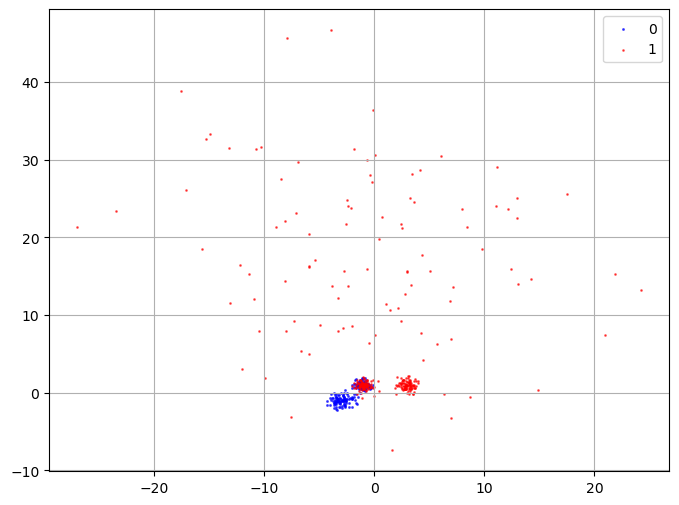

In [29]:
from matplotlib import pyplot as plt

def make_visual():
    X, y = generate_samples(100, 100)

    X0 = X[y == 0]
    X1 = X[y == 1]

    plt.figure(figsize=(8, 6))
    plt.scatter(X0[:, 0], X0[:, 1], color='blue', alpha=0.6, label='0', s=1.3)
    plt.scatter(X1[:, 0], X1[:, 1], color='red', alpha=0.6, label='1', s=0.9)
    plt.legend()
    plt.grid(True)
    plt.show()

make_visual()

In [30]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

def estimate_metrics(model, i):
    #Сгенерировать обучающую выборку заданного размера.
    x_train, y_train = generate_samples(100, 100)

    #Вычислить оценку вероятности ошибочной классификации методом скользящего экзамена
    kfold_scores = 1 - cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

    #Построить решающую функцию. Вычислить эмпирический риск
    model.fit(x_train, y_train)
    emp_risk = 1 - accuracy_score(y_train, model.predict(x_train))

    #Вычислить оценку вероятности ошибочной классификации.
    x_test, y_test = generate_samples(10000, 10000)
    test_risk = 1 - accuracy_score(y_test, model.predict(x_test))

    return pd.Series([i, emp_risk, kfold_scores.mean(), test_risk])

# Повторять шаги 4–7 заданное число раз.
def estimate_metrics_all(model, iterations=100):
    df = pd.DataFrame([estimate_metrics(model, i) for i in range(iterations)])
    df.columns = ['iteration', 'emp_risk', 'kfold_risk', 'test_risk']
    return df

#Вычислить средние и стандартные отклонения по каждому столбцу.
def estimate_mean_metics(model, iterations=100):
    df_means = estimate_metrics_all(model, iterations).mean().drop('iteration')
    df_means.index = df_means.index + '_mean'
    df_dev = estimate_metrics_all(model, iterations).std().drop('iteration')
    df_dev.index = df_dev.index + '_std'
    df = pd.concat([df_means, df_dev], axis=0)
    return df

In [31]:
models_accuracy = pd.DataFrame(columns=['model', 'emp_risk_mean', 'kfold_risk_mean', 'test_risk_mean', 'emp_risk_std', 'kfold_risk_std', 'test_risk_std'])

def add_model(model, model_name, iterations=100):
    global models_accuracy

    s = estimate_mean_metics(model, iterations=iterations)
    s['model'] = model_name
    models_accuracy = pd.concat([models_accuracy, s.to_frame().T], ignore_index=True)
    return models_accuracy

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

add_model(LogisticRegression(), 'LogisticRegression')
add_model(LinearDiscriminantAnalysis(), 'LDA')
add_model(QuadraticDiscriminantAnalysis(), 'QDA')
add_model(GradientBoostingClassifier(), 'GradientBoostingClassifier')
add_model(SVC(kernel='rbf'), 'SVC - rbf')
add_model(SVC(kernel='linear'), 'SVC - linear')
add_model(DecisionTreeClassifier(), 'DecisionTreeClassifier')
add_model(DecisionTreeClassifier(max_depth=4), 'DecisionTreeClassifier_depth=4')
add_model(RandomForestClassifier(), 'RandomForestClassifier')

models_accuracy

,model,emp_risk_mean,kfold_risk_mean,test_risk_mean,emp_risk_std,kfold_risk_std,test_risk_std
0,LogisticRegression,0.2145,0.2166,0.218565,0.01554,0.015837,0.002225
1,LDA,0.2316,0.23238,0.22991,0.011055,0.010633,0.004164
2,QDA,0.20392,0.20424,0.204009,0.003741,0.003944,0.000782
3,GradientBoostingClassifier,0.03148,0.19652,0.194428,0.007735,0.019662,0.004759
4,SVC - rbf,0.19302,0.2014,0.197332,0.009597,0.012595,0.003068
5,SVC - linear,0.2216,0.2238,0.221312,0.011522,0.012041,0.001584
6,DecisionTreeClassifier,0.0,0.19946,0.199005,0.0,0.017741,0.004637
7,DecisionTreeClassifier_depth=4,0.16072,0.2013,0.1967,0.017353,0.018116,0.007425
8,RandomForestClassifier,0.0,0.19312,0.193105,0.0,0.01981,0.003801


In [33]:
def analyze_results(models_accuracy):
    print("Анализ соответствия методов сложности модели и объёма выборки:")
    print(f"Объём обучающей выборки: 500 объектов")
    print(f"Лучшая модель по test_risk: {models_accuracy.loc[models_accuracy['test_risk_mean'].idxmin(), 'model']}")
    print(f"Наиболее устойчивая (min std): {models_accuracy.loc[models_accuracy['test_risk_std'].idxmin(), 'model']}")

analyze_results(models_accuracy)

Анализ соответствия методов сложности модели и объёма выборки:
Объём обучающей выборки: 500 объектов
Лучшая модель по test_risk: RandomForestClassifier
Наиболее устойчивая (min std): QDA
